In [17]:
import forgethreads as ft
import numpy as np



In [18]:

rng = np.random.default_rng()
ft.set_verbose(False)


In [19]:
# n= 100
# distribution = 0.7

# m_size = n ** 2 



# # Llenar segun distribucion

# m1= np.zeros(shape=(1,n,n))

# total_for_fill =  (n * (n-1)) / 2
# total_for_fill_pondered = total_for_fill * distribution

# ni = 0
# while(ni < total_for_fill_pondered):
#   o = rng.integers(0,n)
#   d = rng.integers(0,n)
#   if(m1[0,o,d]) == 0:
#     m1[0,o,d] = 1
#     m1[0,d,o] = 1
#     ni += 1



# m2 = m1.copy()
# paths,values, max_order = ft.maxmin(m1,m2,0.1,200,False)

In [20]:
def create_by_distribution(n, avg_degree):
    """
    Grafo aleatorio dirigido [1, n, n] float16.
    avg_degree: grado promedio de salida por nodo (número de vecinos esperado).
    Aristas existentes: peso ~ U(0.55, 1.0).  No-aristas: peso = 0.
    """
    p = min(avg_degree / max(n - 1, 1), 1.0)
    mask = rng.random((n, n)) < p
    np.fill_diagonal(mask, False)
    weights = rng.uniform(0.55, 1.0, (n, n)).astype(np.float16)
    m1 = np.where(mask, weights, np.float16(0.0)).reshape(1, n, n)
    return m1.astype(np.float16)

In [21]:
def run_experimental(n, avg_degree):
    m1 = create_by_distribution(n, avg_degree)
    m2 = m1.copy()
    paths, values, max_order = ft.maxmin(m1, m2, 0.5, 60)
    return max_order

In [39]:
ns = [10,50,100,200]
avg_degrees = [0.3, 0.5, 0.7, 1.0, 1.5, 2.0, 3.0, 5.0, 8.0, 12.0, 20.0, 40.0]
iterations = 100

proms_by_n = []
for n in ns:
    proms = []
    for deg in avg_degrees:
        acum = 0
        for i in range(iterations):
            acum += run_experimental(n, deg)
        proms.append(acum / iterations)
        print(f"deg={deg} : n={n} ", end="\t")
    print(f"\ncalculated averages for {n} nodes")
    proms_by_n.append(proms)
    
p300 = np.load("proms_300n.npy")
p400 = np.load("proms_400n.npy")
p500 = np.load("proms_500n.npy")

proms_by_n.append(p300[0])
proms_by_n.append(p400[0])
proms_by_n.append(p500[0])

ns = [10,50,100,200,300,400,500]


deg=0.3 : n=10 	deg=0.5 : n=10 	deg=0.7 : n=10 	deg=1.0 : n=10 	deg=1.5 : n=10 	deg=2.0 : n=10 	deg=3.0 : n=10 	deg=5.0 : n=10 	deg=8.0 : n=10 	deg=12.0 : n=10 	deg=20.0 : n=10 	deg=40.0 : n=10 	
calculated averages for 10 nodes
deg=0.3 : n=50 	deg=0.5 : n=50 	deg=0.7 : n=50 	deg=1.0 : n=50 	deg=1.5 : n=50 	deg=2.0 : n=50 	deg=3.0 : n=50 	deg=5.0 : n=50 	deg=8.0 : n=50 	deg=12.0 : n=50 	deg=20.0 : n=50 	deg=40.0 : n=50 	
calculated averages for 50 nodes
deg=0.3 : n=100 	deg=0.5 : n=100 	deg=0.7 : n=100 	deg=1.0 : n=100 	deg=1.5 : n=100 	deg=2.0 : n=100 	deg=3.0 : n=100 	deg=5.0 : n=100 	deg=8.0 : n=100 	deg=12.0 : n=100 	deg=20.0 : n=100 	deg=40.0 : n=100 	
calculated averages for 100 nodes
deg=0.3 : n=200 	deg=0.5 : n=200 	deg=0.7 : n=200 	deg=1.0 : n=200 	deg=1.5 : n=200 	deg=2.0 : n=200 	deg=3.0 : n=200 	deg=5.0 : n=200 	deg=8.0 : n=200 	deg=12.0 : n=200 	deg=20.0 : n=200 	deg=40.0 : n=200 	
calculated averages for 200 nodes


In [40]:
proms_by_n

[[1.01, 8.05, 17.35, 24.08, 23.43, 20.18, 5.5, 1.95, 1.0, 1.0, 1.0, 1.0],
 [5.69, 12.5, 22.07, 35.27, 32.52, 23.9, 9.66, 4.49, 2.99, 2.0, 1.28, 1.0],
 [4.46, 14.45, 26.91, 42.06, 42.36, 23.62, 11.34, 5.43, 3.5, 2.69, 2.0, 1.0],
 [6.07, 16.18, 24.3, 49.9, 41.54, 27.93, 12.57, 6.32, 4.07, 3.02, 2.0, 2.0],
 array([ 6.55, 14.38, 24.3 , 50.19, 46.38, 27.4 , 13.56,  6.9 ,  4.52,
         3.14,  2.1 ,  2.  ]),
 array([ 6.82, 19.28, 28.66, 52.37, 45.5 , 27.66, 14.14,  7.22,  4.8 ,
         3.33,  2.86,  2.  ]),
 array([ 5.71, 16.97, 29.1 , 51.4 , 46.54, 30.23, 14.58,  7.47,  5.04,
         3.78,  3.  ,  2.  ])]

In [41]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

def plot_proms(ns, avg_degrees, proms_by_n):
    fig, ax = plt.subplots(figsize=(10, 6))
    
    colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
    
    for i, n in enumerate(ns):
        color = colors[i % len(colors)]
        ax.plot(avg_degrees, proms_by_n[i], 'o-', label=f"N = {n}", 
                linewidth=2, markersize=5, color=color)
        ax.axvline(x=np.log(n), color=color, linestyle=':', linewidth=1.5, alpha=0.7)

    ax.axvline(x=1.0,  color='gray', linestyle='--', linewidth=1, alpha=0.6)
    ax.axvline(x=10.0, color='gray', linestyle='--', linewidth=1, alpha=0.6)
    ax.set_xscale('log')
    ax.set_xticks(avg_degrees)
    ax.set_xticklabels([str(d) for d in avg_degrees], rotation=30, fontsize=9)
    ax.xaxis.set_minor_formatter(ticker.NullFormatter())
    ax.set_xlabel("Grado promedio (avg_degree)", fontsize=12)
    ax.set_ylabel("E[η₀] — orden máximo promedio", fontsize=12)
    ax.set_title("Orden máximo promedio vs densidad del grafo", fontsize=13)
    
    # Leyenda combinada: curva + ln(n)
    handles, labels = ax.get_legend_handles_labels()
    for i, n in enumerate(ns):
        color = colors[i % len(colors)]
        handles.append(plt.Line2D([0], [0], color=color, linestyle=':', linewidth=1.5, alpha=0.7))
        labels.append(f"ln({n}) = {np.log(n):.2f}")
    
    ax.legend(handles=handles, labels=labels, title="Nodos N", fontsize=10, ncol=2)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [43]:
np.save("all_degrees",proms_by_n)

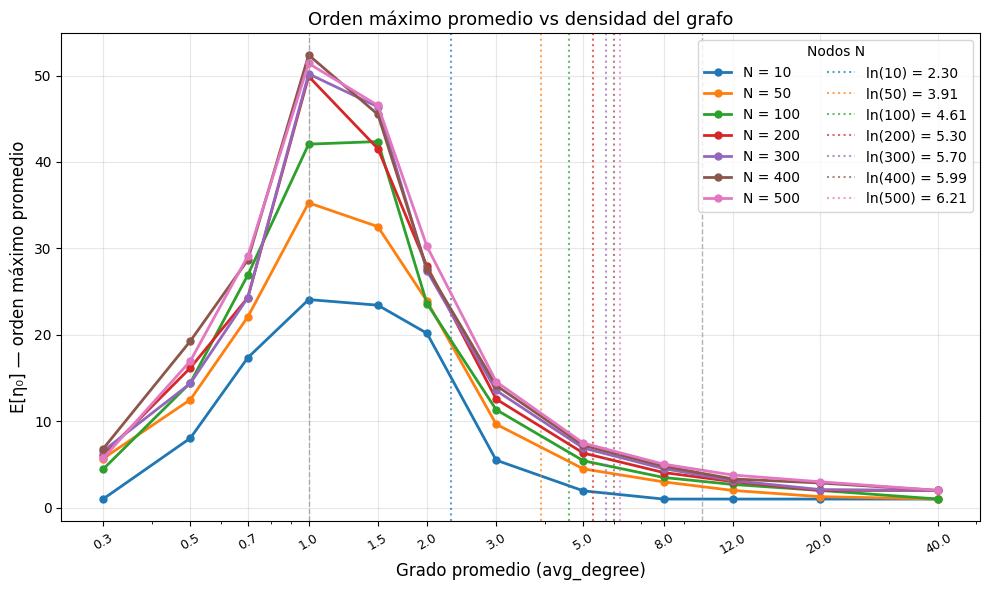

In [42]:
plot_proms(ns, avg_degrees, proms_by_n)

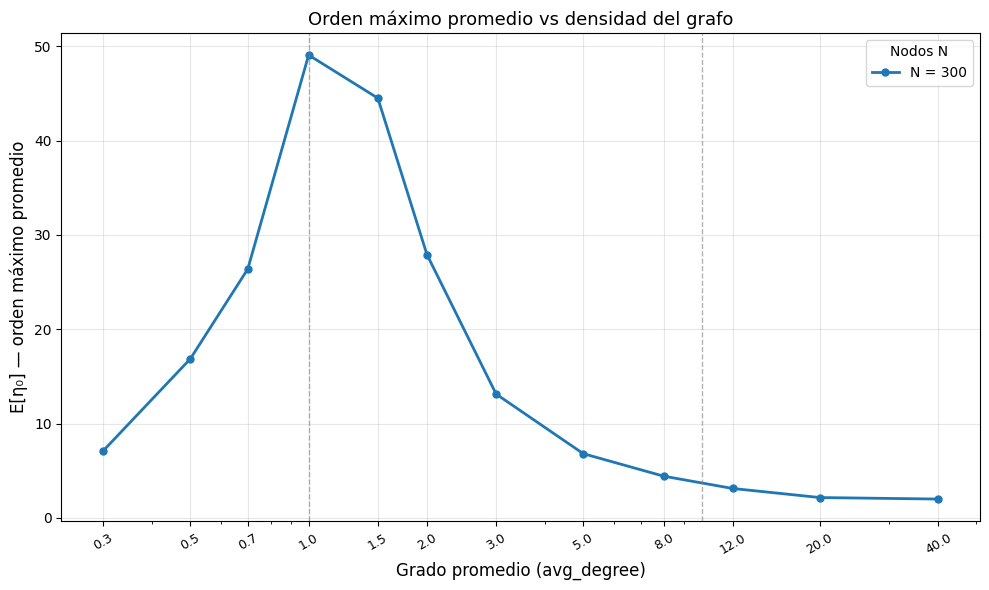

In [31]:
plot_proms(ns, avg_degrees, proms_by_n)


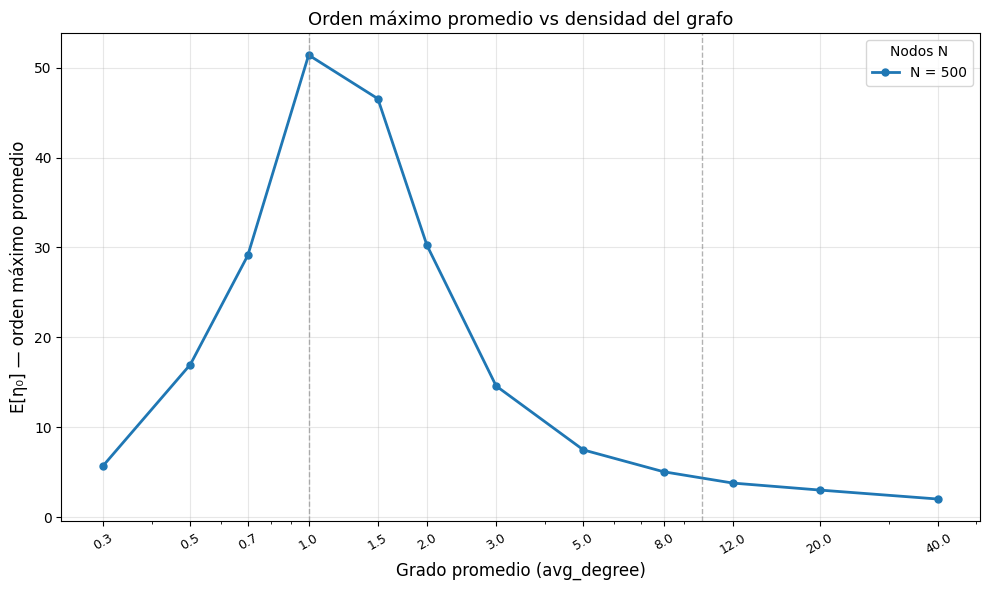

In [33]:
plot_proms(ns, avg_degrees, proms_by_n)
